In [21]:
import pandas as pd

metadata = pd.read_csv("metadata.csv")

metadata

print(metadata.head(25))
print(f"Total subjects: {len(metadata)}")
print(f"Brugada patients: {(metadata['brugada'] > 0).sum()}")
print(f"Healthy subjects: {(metadata['brugada'] == 0).sum()}")

    patient_id  basal_pattern  sudden_death  brugada
0       188981              1             0        1
1       251972              0             0        0
2       265715              0             0        0
3       267628              0             0        0
4       267630              0             0        1
5       286830              0             0        0
6       287355              0             0        0
7       292220              0             0        0
8       292666              0             0        0
9       304141              0             0        0
10      314397              0             0        0
11      316872              0             0        0
12      317547              0             1        0
13      319150              0             0        1
14      319221              0             0        0
15      325231              0             0        0
16      325966              0             0        0
17      329034              0             0   

In [22]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 363 entries, 0 to 362
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   patient_id     363 non-null    int64
 1   basal_pattern  363 non-null    int64
 2   sudden_death   363 non-null    int64
 3   brugada        363 non-null    int64
dtypes: int64(4)
memory usage: 11.5 KB


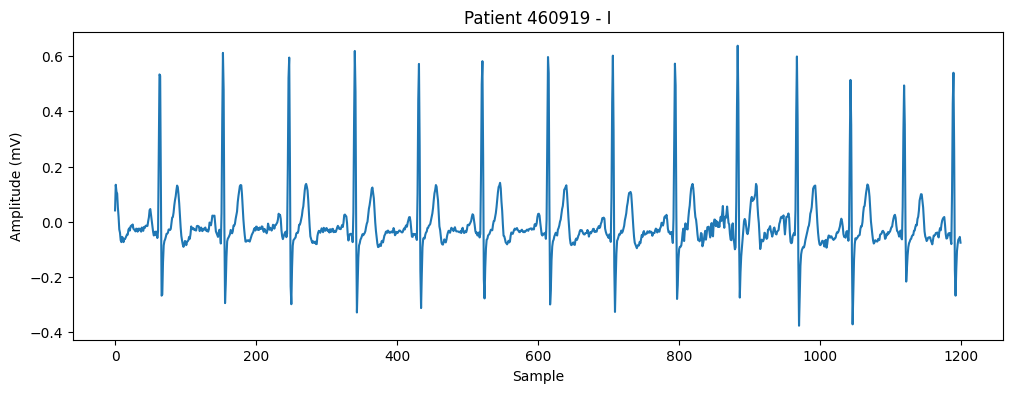

In [23]:
# 2

import wfdb
import matplotlib.pyplot as plt

patient_id = '460919'
record = wfdb.rdrecord(f'files/{patient_id}/{patient_id}')

signals = record.p_signal
lead_names = record.sig_name
sampling_freq = record.fs

plt.figure(figsize=(12, 4))
plt.plot(signals[:, 0])
plt.title(f'Patient {patient_id} - {lead_names[0]}')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.show()

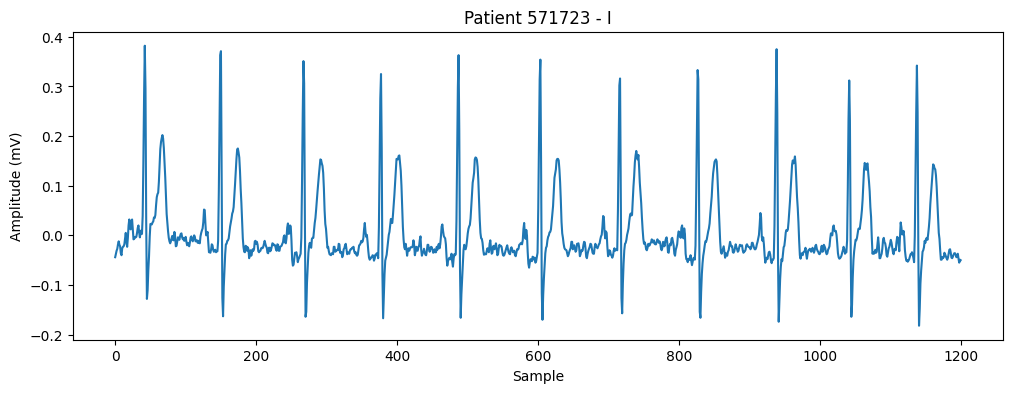

In [24]:
# 2

import wfdb
import matplotlib.pyplot as plt

patient_id = '571723'
record = wfdb.rdrecord(f'files/{patient_id}/{patient_id}')

signals = record.p_signal
lead_names = record.sig_name
sampling_freq = record.fs

plt.figure(figsize=(12, 4))
plt.plot(signals[:, 0])
plt.title(f'Patient {patient_id} - {lead_names[0]}')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.show()

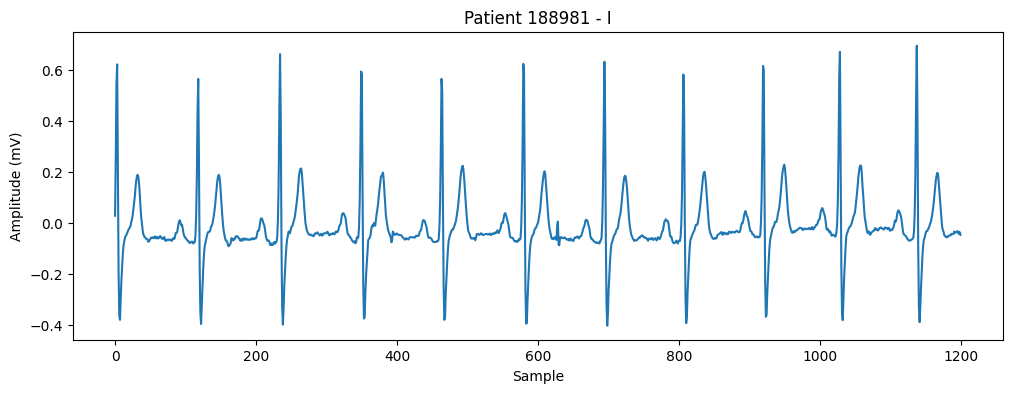

In [25]:
# 1

import wfdb
import matplotlib.pyplot as plt

patient_id = '188981'
record = wfdb.rdrecord(f'files/{patient_id}/{patient_id}')

signals = record.p_signal
lead_names = record.sig_name
sampling_freq = record.fs

plt.figure(figsize=(12, 4))
plt.plot(signals[:, 0])
plt.title(f'Patient {patient_id} - {lead_names[0]}')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.show()

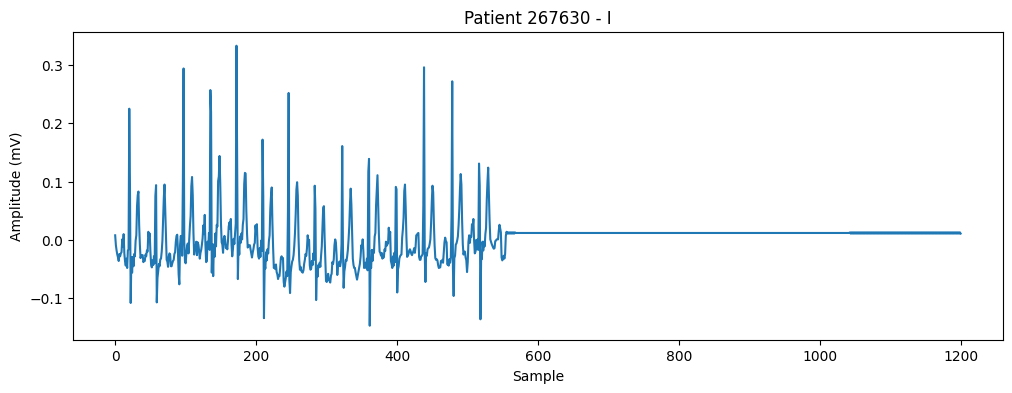

In [26]:
# 1

import wfdb
import matplotlib.pyplot as plt

patient_id = '267630'
record = wfdb.rdrecord(f'files/{patient_id}/{patient_id}')

signals = record.p_signal
lead_names = record.sig_name
sampling_freq = record.fs

plt.figure(figsize=(12, 4))
plt.plot(signals[:, 0])
plt.title(f'Patient {patient_id} - {lead_names[0]}')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.show()

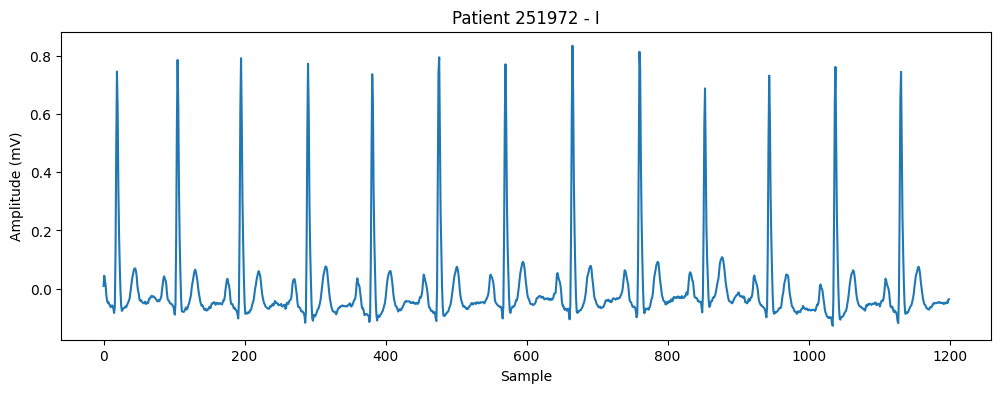

In [27]:
# 0

import wfdb
import matplotlib.pyplot as plt

patient_id = '251972'
record = wfdb.rdrecord(f'files/{patient_id}/{patient_id}')

signals = record.p_signal
lead_names = record.sig_name
sampling_freq = record.fs

plt.figure(figsize=(12, 4))
plt.plot(signals[:, 0])
plt.title(f'Patient {patient_id} - {lead_names[0]}')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.show()

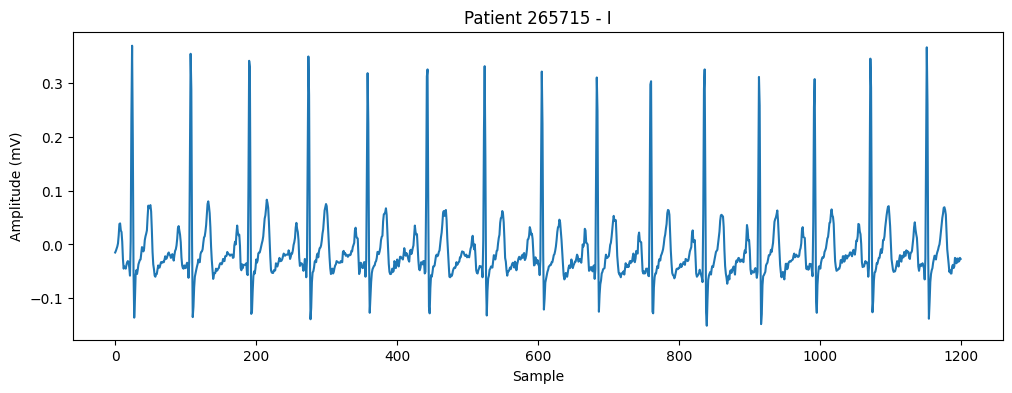

In [28]:
# 0

import wfdb
import matplotlib.pyplot as plt

patient_id = '265715'
record = wfdb.rdrecord(f'files/{patient_id}/{patient_id}')

signals = record.p_signal
lead_names = record.sig_name
sampling_freq = record.fs

plt.figure(figsize=(12, 4))
plt.plot(signals[:, 0])
plt.title(f'Patient {patient_id} - {lead_names[0]}')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.show()

In [29]:
import pandas as pd

df = pd.read_csv("metadata.csv")

df

,patient_id,basal_pattern,sudden_death,brugada
0,188981,1,0,1
1,251972,0,0,0
2,265715,0,0,0
3,267628,0,0,0
4,267630,0,0,1
...,...,...,...,...
358,3128957,0,0,0
359,3133602,0,0,0
360,3136075,0,0,0
361,3138453,0,0,0


In [30]:
df["brugada"].value_counts()

brugada
0    287
1     69
2      7
Name: count, dtype: int64

In [31]:
df = df[df["brugada"] == 2]
df

,patient_id,basal_pattern,sudden_death,brugada
30,460919,0,0,2
51,571723,1,1,2
75,822108,1,0,2
79,841212,0,0,2
104,945345,1,0,2
242,1290807,1,0,2
316,3016396,0,0,2


In [32]:
import wfdb
import numpy as np
import pandas as pd
import neurokit2 as nk
from scipy.signal import butter, filtfilt

In [33]:
def bandpass_filter(signal, low=0.2, high=40, fs=100):
    b, a = butter(2, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, signal)

In [34]:
metadata = pd.read_csv("metadata.csv")
metadata.head()

,patient_id,basal_pattern,sudden_death,brugada
0,188981,1,0,1
1,251972,0,0,0
2,265715,0,0,0
3,267628,0,0,0
4,267630,0,0,1


In [35]:
patient_id = str(metadata.iloc[0]["patient_id"])
record_path = f"files/{patient_id}/{patient_id}"

record = wfdb.rdrecord(record_path)
signal = record.p_signal

print(signal.shape)

(1200, 12)


In [36]:
v1 = signal[:, 6]
v2 = signal[:, 7]
v3 = signal[:, 8]

In [37]:
v1 = bandpass_filter(v1)
v2 = bandpass_filter(v2)
v3 = bandpass_filter(v3)

In [38]:
signals, info = nk.ecg_process(v1, sampling_rate=100)
r_peaks = info["ECG_R_Peaks"]

print(r_peaks[:10])

[ 115  231  347  461  577  691  804  917 1025 1134]


In [39]:
st_values = []
slopes = []
qrs_durations = []
t_amplitudes = []
t_polarities = []

for r in r_peaks:
    if r-10 < 0 or r+60 >= len(v1):
        continue

    baseline = v1[r-10]
    st_point = v1[r+2]
    st = st_point - baseline
    st_values.append(st)

    slope = (v1[r+8] - v1[r+2]) / 6
    slopes.append(slope)

    qrs = (r+5) - (r-5)
    qrs_durations.append(qrs_durations)

    t_wave = v1[r+20:r+50]
    if len(t_wave) > 0:
        t_amp = np.max(t_wave)
        t_amplitudes.append(t_wave)
        t_polarities.append(1 if t_amp > 0 else 0)

In [ ]:
features_v1 = {
    "st_mean_V1": np.mean(st_values),
    "st_max_V1": np.max(st_values),
    "slope_mean_V1": np.mean(slopes),
    "qrs_mean_V1": np.mean(qrs_durations),
    "t_amp_mean_V1": np.mean(t_amplitudes),
    "t_polarity_V1": np.mean(t_polarities),
    "mean_V1": np.mean(v1),
    "std_V1": np.std(v1),
    "max_V1": np.max(v1),
    "min_V1": np.min(v1)
}

features_v1

MemoryError: 

In [ ]:
all_data = []

for i, row in metadata.iterrows():
    patient_id = str(row["patient_id"])
    record_path = f"files/{patient_id}/{patient_id}"

    try:
        record = wfdb.rdrecord(record_path)
        signal = record.p_signal

        v1 = bandpass_filter(signal[:, 6])

        signals, info = nk.ecg_process(v1, sampling_rate=100)
        r_peaks = info["ECG_R_Peaks"]

        st_values = []
        slopes = []
        qrs_durations = []
        t_amplitudes = []
        t_polarities = []

        for r in r_peaks:
            if r-10 < 0 or r+60 >= len(v1):
                continue

            st = v1[r+2] - v1[r-10]
            st_values.append(st)

            slope = (v1[r+8] - v1[r+2]) / 6
            slopes.append(slope)

            qrs_durations.append(10)

            t_wave = v1[r+20:r+50]
            if len(t_wave) > 0:
                t_amp = np.max(t_wave)
                t_amplitudes.append(t_amp)
                t_polarities.append(1 if t_amp > 0 else 0)

        features = {
            "st_mean": np.mean(st_values) if st_values else 0,
            "st_max": np.max(st_values) if st_values else 0,
            "slope_mean": np.mean(slopes) if slopes else 0,
            "qrs_mean": np.mean(qrs_durations) if qrs_durations else 0,
            "t_amp_mean": np.mean(t_amplitudes) if t_amplitudes else 0,
            "t_polarity": np.mean(t_polarities) if t_polarities else 0,
            "mean": np.mean(v1),
            "std": np.std(v1),
            "max": np.max(v1),
            "min": np.min(v1),
            "basal_pattern": row["basal_pattern"],
            "sudden_death": row["sudden_death"],
            "label": row["brugada"]
        }

        all_data.append(features)

    except:
        continue

    if i % 20 == 0:
        print("Processed:", i)

In [ ]:
df = pd.DataFrame(all_data)
df.head()

In [ ]:
df.to_csv("ecg_features", index=False)

In [ ]:
import os
import pandas as pd
import numpy as np
import wfdb
from scipy.stats import skew, kurtosis
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

DATASET_ROOT = r"E:\IDSC\brugada-huca-12-lead-ecg-recordings-for-the-study-of-brugada-syndrome-1.0.0"
METADATA_PATH = os.path.join(DATASET_ROOT, "metadata.csv")
FILES_DIR = os.path.join(DATASET_ROOT, "files")

# Fungsi mengekstrak fitur dari 3 sinyal (V1, V2, V3) lalu menggabungkannya
def extract_multilead_features(v1, v2, v3):
    features = []
    for signal in [v1, v2, v3]:
        features.extend([
            np.mean(signal),
            np.std(signal),
            np.max(signal),
            np.min(signal),
            np.max(signal) - np.min(signal),
            skew(signal),
            kurtosis(signal)
        ])
    return features

In [ ]:
metadata = pd.read_csv(METADATA_PATH)

X_data = []
y_data = []

print("Mengekstrak fitur dari Lead V1, V2, dan V3. Harap tunggu...")

for index, row in metadata.iterrows():
    patient_id = str(row['patient_id'])
    label = row['brugada']

    # Hanya ambil Normal (0) dan Brugada (1) agar SMOTE bisa bekerja
    if label not in [0, 1]:
        continue

    record_path = os.path.join(FILES_DIR, patient_id, patient_id)

    try:
        record = wfdb.rdrecord(record_path)
        
        # Ambil indeks untuk V1, V2, V3 (Atau default ke 6, 7, 8 jika nama persis tidak ditemukan)
        idx_v1 = record.sig_name.index('V1') if 'V1' in record.sig_name else 6
        idx_v2 = record.sig_name.index('V2') if 'V2' in record.sig_name else 7
        idx_v3 = record.sig_name.index('V3') if 'V3' in record.sig_name else 8
        
        sig_v1 = record.p_signal[:, idx_v1]
        sig_v2 = record.p_signal[:, idx_v2]
        sig_v3 = record.p_signal[:, idx_v3]

        # Bersihkan NaN
        sig_v1 = np.nan_to_num(sig_v1) if np.isnan(sig_v1).any() else sig_v1
        sig_v2 = np.nan_to_num(sig_v2) if np.isnan(sig_v2).any() else sig_v2
        sig_v3 = np.nan_to_num(sig_v3) if np.isnan(sig_v3).any() else sig_v3

        features = extract_multilead_features(sig_v1, sig_v2, sig_v3)
        
        X_data.append(features)
        y_data.append(label)
        
    except Exception as e:
        pass

X = np.array(X_data)
y = np.array(y_data)

print(f"Total data berhasil diekstrak: {len(X)}")

Mengekstrak fitur dari Lead V1, V2, dan V3. Harap tunggu...
Total data berhasil diekstrak: 356


In [ ]:
if len(X) > 0:
    # 1. Split data (80% Train, 20% Test)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"Jumlah label latih SEBELUM SMOTE: Normal={sum(y_train==0)}, Brugada={sum(y_train==1)}")
    
    # 2. Terapkan SMOTE HANYA pada data latih (Train data)
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    
    print(f"Jumlah label latih SESUDAH SMOTE: Normal={sum(y_train_smote==0)}, Brugada={sum(y_train_smote==1)}")

    # 3. Training Model
    print("\nMelatih model Random Forest...")
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train_smote, y_train_smote)

    # 4. Prediksi (Gunakan X_test yang ASLI, tidak di-SMOTE)
    y_pred = rf_model.predict(X_test)
    print("Training selesai!")
else:
    print("Data kosong.")

Jumlah label latih SEBELUM SMOTE: Normal=229, Brugada=55
Jumlah label latih SESUDAH SMOTE: Normal=229, Brugada=229

Melatih model Random Forest...
Training selesai!


HASIL KLASIFIKASI RF (SMOTE + 3 LEADS)
Akurasi Keseluruhan: 79.17%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.85      0.90      0.87        58
     Brugada       0.45      0.36      0.40        14

    accuracy                           0.79        72
   macro avg       0.65      0.63      0.64        72
weighted avg       0.78      0.79      0.78        72



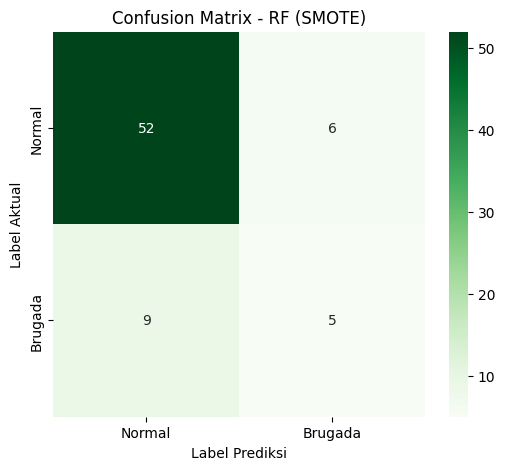

In [ ]:
print("="*40)
print("HASIL KLASIFIKASI RF (SMOTE + 3 LEADS)")
print("="*40)

print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

target_names = ['Normal', 'Brugada']
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - RF (SMOTE)')
plt.ylabel('Label Aktual')
plt.xlabel('Label Prediksi')
plt.show()